# **Ising Calibration Agent with NVIDIA AI Foundation Models**

[**build.nvidia.com**](https://build.nvidia.com/) offers **NVIDIA Inference Microservices (NIM)**,
allowing developers to experience state-of-the-art models accelerated on NVIDIA GPUs anywhere.
One of them is [**NVIDIA Ising Calibration 1.5**](https://build.nvidia.com/nvidia/ising-calibration-1.5-31b) —
a vision-language model (VLM) that reads **quantum-calibration plots** the way an experimentalist does.

In this warm-up you will:

1. **Open the Ising Calibration playground** at
   [build.nvidia.com/nvidia/ising-calibration-1.5-31b](https://build.nvidia.com/nvidia/ising-calibration-1.5-31b)
   and try the browser chat.
2. **Simulate a calibration experiment yourself** — resonator spectroscopy, run live with
   the **CUDA-Q Dynamics API** on the GPU.
3. **Query the agent with your data** — attach the plot and ask it to explain the results
   in all six question styles it was trained on.
4. **Go further in the optional Appendix** — the rest of the bring-up chain (qubit
   spectroscopy, Rabi, $T_1$, Ramsey), a drifting-resonator case study for the agent to
   diagnose, and dispersive readout.

Python dependencies come from the repo's `requirements.txt` (`pip install -r requirements.txt`);
CUDA-Q and an NVIDIA GPU are preinstalled in the bootcamp environment.

Sign up for free credits on [build.nvidia.com](https://build.nvidia.com/), generate an API key,
and paste it into the following cell:

In [ ]:
# Cell 1 — set your build.nvidia.com API key
import os

api_key = "Paste your API key here (must include prefix: nvapi-)"

if api_key.startswith("nvapi-"):
    os.environ["NVIDIA_API_KEY"] = api_key
api_key = os.environ.get("NVIDIA_API_KEY", api_key)

if api_key.startswith("nvapi-"):
    print("API key set.")
else:
    print("No valid key yet — the query cells below will print instructions instead of answers.")

API key set.


### Part I: Meet the model

**NVIDIA Ising Calibration 1.5** (`nvidia/ising-calibration-1.5-31b`) is a dense multimodal
vision-language model built on Gemma 4 31B and fine-tuned for quantum calibration plot
understanding. The family was released with **QCalEval**
([arXiv:2604.25884](https://arxiv.org/abs/2604.25884)), the first benchmark for this task —
243 samples across 22 experiment families spanning superconducting qubits and neutral atoms.
Version 1.5 scores **74.5 zero-shot** and **81.2 with multi-image in-context learning**, its
headline upgrade: show it a few plots from a related experiment and it reads unfamiliar
diagnostics far better. It also ships NVFP4-quantized, so it fits on a single GPU or a
[DGX Spark](https://www.nvidia.com/en-us/products/workstations/dgx-spark/).

This tutorial queries it **zero-shot** and walks through the **six question types** it was
trained on — the VLM will answer all of them. Phrasing your prompts in these styles plays to
its strengths:

| # | Question type | What you ask |
|---|---|---|
| Q1 | Technical description | describe the plot type, axes, salient features |
| Q2 | Experimental conclusion | classify: Expected behavior / Suboptimal parameters / Anomalous behavior / Apparatus issue |
| Q3 | Experimental significance | what the pattern implies; is the sweep sufficient; what calibration step follows |
| Q4 | Fit reliability | is the overlaid fit Reliable / Unreliable / No fit |
| Q5 | Parameter extraction | machine-readable JSON of physical parameters |
| Q6 | Calibration diagnosis | a status code (e.g. `SUCCESS`, `NO_SIGNAL`, `AMP_TOO_HIGH`) plus corrective action |

### Part II: Simulate a calibration plot with CUDA-Q Dynamics

The VLM needs an experiment image — here, **resonator spectroscopy**, the *very first*
measurement of any bring-up: before you can even see the qubit, you must find the **readout
resonator** it is coupled to.

The resonator is a harmonic oscillator with frequency $f_r$ and linewidth $\kappa$ (photon
loss). Sweep a weak probe tone across the band and record the transmitted magnitude
$|S_{21}|$: on resonance the resonator absorbs the probe — a **narrow dip** at $f_r$, of
width $\kappa$ — and a Lorentzian fit reports the frequency with its uncertainty, exactly
how the plot comes out of a real lab stack. (Strictly, this $f_r$ is the qubit-*dressed*
frequency $\omega_r - g^2/\Delta$ —
[Blais *et al.*, PRA **69**, 062320](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.69.062320);
A.7 shows the pull.)

The data is simulated live with the **CUDA-Q Dynamics API**
([docs](https://nvidia.github.io/cuda-quantum/latest/using/dynamics.html),
[more examples](https://nvidia.github.io/cuda-quantum/latest/using/examples/dynamics_examples.html#python-examples-jupyter-notebooks))
— the GPU-accelerated Lindblad master-equation solver behind `cudaq.set_target("dynamics")`,
and this notebook's second key takeaway. The handful of APIs used throughout, introduced once:

- **Operators** — `operators.annihilate/create/number` (and `spin.z` later) compose
  Hamiltonians and collapse operators algebraically.
- **`cudaq.evolve(H, dimensions, Schedule(...), state, collapse_operators=...,
  observables=..., integrator=RungeKuttaIntegrator(...))`** — integrates the Lindblad
  master equation on the GPU.
- **[Batch simulation](https://nvidia.github.io/cuda-quantum/latest/using/dynamics.html#batch-simulation)** —
  the advanced trick every sweep here leans on: pass a *list* of Hamiltonians (and
  optionally initial states) and one fused call integrates them all at once.

In the frame rotating at the probe — time in ns, frequency in GHz, explicit $2\pi$
everywhere — a sweep is a *family of independent experiments*, one frozen Hamiltonian per
probe point $f_{p,k}$, each rung up to steady state:

$$H_k/\hbar = 2\pi\,(f_r - f_{p,k})\,\hat N \;+\; 2\pi\,\frac{\varepsilon}{2}\,(\hat a + \hat a^\dagger),
\qquad \text{photon loss } \sqrt{2\pi\kappa}\,\hat a.$$

Everything is yours to break — change `f_r_true` or `kappa`, re-run, and the plot (and the
agent's reading of it) really changes. Read the plot yourself before asking the agent: where
is the dip, how wide, is the signal usable?

In [2]:
# Cell 2 — CUDA-Q Dynamics setup: solver target, operators, the virtual resonator
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

with warnings.catch_warnings():
    warnings.simplefilter("ignore")     # some environments emit a harmless CuPy
    import cudaq                        # install warning at import time
from cudaq import operators, spin, RungeKuttaIntegrator
from cudaq.dynamics import Schedule, InitialState

cudaq.set_target("dynamics")            # GPU master-equation solver
cudaq.set_random_seed(1234)
rng = np.random.default_rng(1234)

# ladder operators — dimension-agnostic; the Hilbert-space size is set by the
# dimensions map handed to each evolve call
a = operators.annihilate(0)
a_dag = operators.create(0)
N = operators.number(0)

# the virtual resonator — change these, re-run, and the plots really change
f_r_true = 7.250          # GHz   readout resonator frequency
kappa = 0.0015            # GHz   resonator linewidth (FWHM)
epsilon = 0.0002          # GHz   weak probe amplitude (~0.02 photons on resonance)
s21_depth = 0.85          #       dip contrast of the readout line
s21_noise = 0.02          #       analog readout noise (std dev)

n_ref = (epsilon / kappa) ** 2                        # on-resonance photon number
dims_res = {0: 6}                                     # plenty for a weak probe
res_collapse = [np.sqrt(2.0 * np.pi * kappa) * a]     # photon loss at rate kappa

vac = np.zeros(dims_res[0], dtype=np.complex128)
vac[0] = 1.0
res_vacuum = cudaq.State.from_data(vac)

# ring up to steady state: ~20 photon lifetimes (lifetime 1/(2*pi*kappa) ~ 106 ns)
ring_up_ts = np.linspace(0.0, 20.0 / (2.0 * np.pi * kappa), 21)

def lorentzian_dip(f, offset, depth, f0, hwhm):
    return offset - depth * hwhm**2 / ((f - f0)**2 + hwhm**2)

def to_s21(n_ss):
    """Steady-state photon number -> measured |S21| trace, with readout noise."""
    return 1.0 - s21_depth * (n_ss / n_ref) + rng.normal(0.0, s21_noise, n_ss.shape)

def fit_dip(freqs, s21, p0=None):
    """Lorentzian fit seeded at the deepest point; (None, None) if no dip fits."""
    if p0 is None:
        p0 = [1.0, s21_depth, freqs[np.argmin(s21)], 0.001]
    try:
        return curve_fit(lorentzian_dip, freqs, s21, p0=p0)
    except RuntimeError:                # nothing dip-like in the window (NO_SIGNAL)
        return None, None

def steady_n(results):
    """Final <N> of each batched system; expectation_values() is [time][observable]."""
    return np.array([r.expectation_values()[-1][0].expectation() for r in results])

print("CUDA-Q dynamics target ready.")

CUDA-Q dynamics target ready.


101 simulations in one batched evolve call: 3 s
fitted f_r = (7.24999 +/- 0.00001) GHz   (truth 7.2500 GHz)
fitted linewidth kappa = 1.53 MHz   (truth 1.50 MHz)


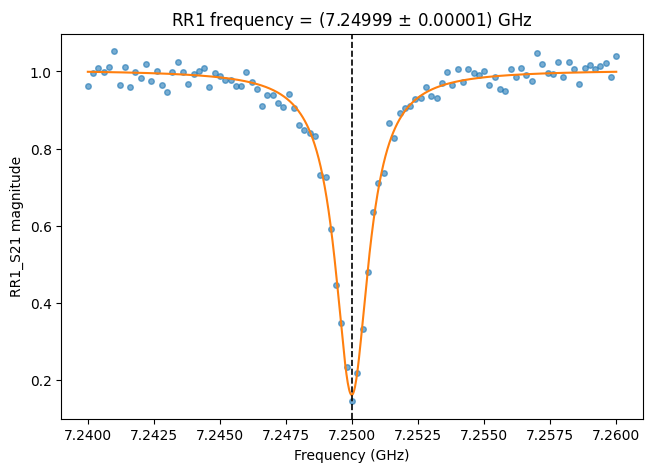

In [3]:
# Cell 3 — the resonator sweep: 101 probe points in ONE batched evolve call
res_freqs = f_r_true + np.linspace(-0.010, 0.010, 101)   # GHz probe window: f_r +/- 10 MHz

res_hams = [2.0 * np.pi * ((f_r_true - fp) * N + (epsilon / 2.0) * (a + a_dag))
            for fp in res_freqs]

t0 = time.perf_counter()
res_results = cudaq.evolve(res_hams, dims_res,
                           Schedule(ring_up_ts, ["t"]),
                           res_vacuum,
                           collapse_operators=[res_collapse] * len(res_hams),
                           observables=[N],
                           store_intermediate_results=cudaq.IntermediateResultSave.NONE,
                           integrator=RungeKuttaIntegrator(order=4, max_step_size=1.0))
n_ss = steady_n(res_results)
print(f"{len(res_freqs)} simulations in one batched evolve call: "
      f"{time.perf_counter() - t0:.0f} s")

s21_meas = to_s21(n_ss)
res_popt, res_pcov = fit_dip(res_freqs, s21_meas)

if res_popt is not None:
    f_r_fit, f_r_err = res_popt[2], np.sqrt(np.diag(res_pcov))[2]
    title = f"RR1 frequency = ({f_r_fit:.5f} $\\pm$ {f_r_err:.5f}) GHz"
    print(f"fitted f_r = ({f_r_fit:.5f} +/- {f_r_err:.5f}) GHz   (truth {f_r_true:.4f} GHz)")
    print(f"fitted linewidth kappa = {2.0 * abs(res_popt[3]) * 1e3:.2f} MHz   "
          f"(truth {kappa * 1e3:.2f} MHz)")
else:
    title = "RR1 resonator scan — no fit found"

plot_dir = "calibration_plots"
os.makedirs(plot_dir, exist_ok=True)
plot_path = f"{plot_dir}/resonator_spectroscopy.png"

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(res_freqs, s21_meas, s=16, alpha=0.6)
if res_popt is not None:
    rf_fine = np.linspace(res_freqs[0], res_freqs[-1], 800)
    ax.plot(rf_fine, lorentzian_dip(rf_fine, *res_popt), color="tab:orange")
    ax.axvline(f_r_fit, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("RR1_S21 magnitude")
ax.set_title(title)
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

### Part III: Describe the plot, then ask for the conclusion

The agent answers over the NVIDIA LLM API gateway at `https://integrate.api.nvidia.com/v1`
— the plot travels as a base64 `image_url`, and the model card's zero-shot settings are
`temperature=0.2` with `max_tokens=8192` (in-context-learning work goes up to 32767).
The helper below wraps one request, then asks the first two question types in order: **Q1**
(technical description — the benchmark's universal prompt: describe the plot as structured
JSON before interpreting it) and **Q2** (experimental conclusion — the 4-way outcome
classification).

In [4]:
# Cell 4 — one helper, then Q1 (describe) and Q2 (conclude) on the plot
import base64
import requests

invoke_url = "https://integrate.api.nvidia.com/v1/chat/completions"
model_id = "nvidia/ising-calibration-1.5-31b"

def ask_agent(image_path, question, max_tokens=8192):
    # Send one calibration plot + one question to the Ising Calibration agent.
    key = os.environ.get("NVIDIA_API_KEY", "")
    if not key.startswith("nvapi-"):
        return ("[no NVIDIA_API_KEY set — paste your key in Cell 1 and re-run; "
                "get one free at https://build.nvidia.com/nvidia/ising-calibration-1.5-31b]")
    with open(image_path, "rb") as f:
        image_b64 = base64.b64encode(f.read()).decode()
    payload = {
        "model": model_id,
        "temperature": 0.2,             # the model card's zero-shot settings
        "top_p": 0.95,
        "max_tokens": max_tokens,
        "messages": [{
            "role": "user",
            "content": [
                {"type": "text", "text": question},
                {"type": "image_url",
                 "image_url": {"url": f"data:image/png;base64,{image_b64}"}},
            ],
        }],
    }
    headers = {"Authorization": f"Bearer {key}", "Accept": "application/json"}
    response = requests.post(invoke_url, headers=headers, json=payload, timeout=300)
    if response.status_code != 200:
        return f"[request failed ({response.status_code}): {response.text}]"
    return response.json()["choices"][0]["message"]["content"]

# Q1 — technical description: the benchmark's universal prompt, same for every
# experiment family. Pure visual grounding, no interpretation yet.
q1_question = (
    "Describe this plot as JSON with fields: plot_type, x_axis, y_axis, "
    "main_features."
)
print("=== Q1 - technical description ===")
print(ask_agent(plot_path, q1_question))

# Q2 — experimental conclusion: the 4-way outcome classification.
q2_question = (
    "This is a resonator spectroscopy measurement of a superconducting readout "
    "resonator: transmitted |S21| magnitude vs. probe frequency, where the "
    "resonator appears as a dip. Classify the outcome as Expected behavior / "
    "Suboptimal parameters / Anomalous behavior / Apparatus issue, and explain "
    "the reasoning from the visible features."
)
print("\n=== Q2 - experimental conclusion ===")
print(ask_agent(plot_path, q2_question))

=== Q1 - technical description ===


```json
{
  "plot_type": "scatter with fitted curve",
  "x_axis": "Frequency (GHz)",
  "y_axis": "RR1_S21 magnitude",
  "main_features": "The plot shows a sharp, symmetric dip in the RR1_S21 magnitude, characteristic of a resonance. The data points (blue dots) are fitted with a smooth orange curve. A vertical dashed line marks the center of the resonance at approximately 7.2500 GHz, which is also stated in the title as the RR1 frequency with an uncertainty of ±0.00001 GHz."
}
```

=== Q2 - experimental conclusion ===


Based on the provided spectroscopy plot, here is the analysis:

**Classification:** Expected behavior

**Reasoning:**
1.  **Resonator Dip:** The plot displays a clear, sharp dip in the transmission magnitude ($|S21|$) centered around 7.25 GHz. This is the characteristic signature of a superconducting readout resonator being probed at its resonant frequency.
2.  **Lorentzian Fit:** The orange curve represents a Lorentzian fit to the data points (blue dots). The fit closely follows the experimental data, accurately capturing the resonance dip and the baseline transmission.
3.  **Frequency Precision:** The title explicitly states the fitted frequency as $7.24999 \pm 0.00001$ GHz. This high precision indicates a well-defined resonance with minimal noise or distortion.
4.  **Baseline Stability:** The transmission magnitude stabilizes at approximately 1.0 away from the resonance (both to the left and right), which is typical for a properly coupled resonator in a transmission line setup.

The

### Part IV: Significance, fit reliability, parameters, and a diagnosis

One plot may induce many questions. The four below cover the remaining QCalEval formats the
agent was trained on: **Q3** (significance — *what does it mean and what should I calibrate
next?*), **Q4** (fit reliability — is the overlaid curve trustworthy: Reliable / Unreliable /
No fit), **Q5** (parameter extraction as machine-readable JSON, in the benchmark's schema
style for this experiment family), and **Q6** (an operational status code). Q5-style answers
are what an automated calibration loop would parse and feed back into the experiment stack.
Together with Q1 and Q2 above, all **six QCalEval question types** now run on this plot.

In [5]:
# Cell 5 — the remaining question types (Q3, Q4, Q5, Q6) on the same plot
followups = {
    "Q3 - experimental significance": (
        "Explain what this resonator spectroscopy plot implies about the device: "
        "is the resonance well resolved, what does the dip width say about the "
        "resonator linewidth kappa, whether the sweep window and resolution were "
        "sufficient, and what the next calibration step should be."
    ),
    "Q4 - fit reliability": (
        "A fitted curve is overlaid on the measured data points in this resonator "
        "spectroscopy plot. Assess whether the fit is trustworthy for parameter "
        "extraction: Reliable, Unreliable, or No fit — and justify the assessment "
        "from the plot."
    ),
    "Q5 - parameter extraction": (
        "Extract from this resonator spectroscopy plot as JSON: "
        '{"f_r_MHz": float, "linewidth_kappa_MHz": float, "dip_visible": bool, '
        '"measurement_usable": bool}.'
    ),
    # AMP_TOO_HIGH from Part I is a qubit-spectroscopy status; a resonator scan
    # chooses from the two that apply here.
    "Q6 - calibration diagnosis": (
        "Assign this resonator spectroscopy result a status from {SUCCESS, "
        "NO_SIGNAL} and, if not SUCCESS, suggest the corrective action."
    ),
}

for name, q in followups.items():
    print(f"=== {name} ===")
    print(ask_agent(plot_path, q))
    print()

=== Q3 - experimental significance ===


Based on the provided spectroscopy plot, here is an analysis of the device performance and the implications for calibration:

**Resonance Characteristics**
The plot displays a classic Lorentzian dip, indicating a high-quality factor (high-Q) resonator. The resonance is extremely well-resolved; the data points (blue dots) follow the fitted curve (orange line) very closely, and the dip is sharp and distinct against the noise floor. The title explicitly states the resonance frequency is $f_r = 7.24999 \pm 0.00001$ GHz, which implies a very precise measurement with minimal uncertainty. The narrow width of the dip suggests a small linewidth $\kappa$, meaning the resonator has low energy loss and a long photon lifetime.

**Sweep Parameters and Resolution**
The frequency sweep window (7.2400 GHz to 7.2600 GHz) was well-chosen. It is wide enough to capture the full baseline of the resonance on both sides, which is crucial for accurate fitting, but narrow enough to provide high resolution aroun

Based on the provided resonator spectroscopy plot, here is the assessment:

**Assessment:** Reliable

**Reasoning:** The orange fitted curve accurately traces the experimental data points (blue dots) across the entire frequency range. The fit successfully captures the characteristic Lorentzian dip of the resonator, including the baseline magnitude, the sharp resonance frequency, and the symmetric recovery on the other side. The residuals appear random and small, indicating that the model appropriately describes the physical behavior of the system, making the extracted parameters (like the center frequency) trustworthy.

=== Q5 - parameter extraction ===


{"f_r_MHz": 7249.99, "linewidth_kappa_MHz": 1.27, "dip_visible": true, "measurement_usable": true}

=== Q6 - calibration diagnosis ===


Status: SUCCESS
Corrective action: None required



### Part V: Bring your own experiments

You have the full loop now: *simulate with CUDA-Q Dynamics, plot in, expert reading out*.
Two ways to go further:

- **Continue in the optional Appendix.** Four more bring-up experiments — qubit
  spectroscopy, Rabi, $T_1$, Ramsey — then two resonator case studies: a **drifting
  resonator** handed to the agent for an open diagnosis (A.6), and **dispersive readout**,
  the physics that makes the resonator a qubit meter (A.7). Six more agent-ready plots land
  in `calibration_plots/` — re-run the `ask_agent(...)` cells above on any of them; the
  Rabi plot with a Q4 *fit reliability* question is a good one.
- **Try the browser playground.** The same model runs interactively at
  [build.nvidia.com/nvidia/ising-calibration-1.5-31b](https://build.nvidia.com/nvidia/ising-calibration-1.5-31b)
  — attach a plot and chat, no code required.

The most interesting experiments are the *broken* ones — edit a parameter, re-run the cell,
and see whether the agent catches each failure:

- **`NO_SIGNAL`** — in Cell 3, sweep `res_freqs` over `7.30–7.32` GHz (or in A.2, the qubit
  `freqs` over `4.20–4.50` GHz) so the resonance sits outside the window.
- **`AMP_TOO_HIGH`** — crank `omega_probe` to `0.10` in A.2 so the qubit line power-broadens
  further and the two-photon $f_{02}/2$ dip at 4.690 GHz grows in.
- **Dying qubit** — set `T1 = 3000` ns *and* `T2_star = 4000` ns in A.1 (keep
  $T_2^* \le 2T_1$, or the pure-dephasing rate turns negative) and ask what the agent would
  recalibrate first.

That closed loop — *simulate → plot → let an agent read it → act* — is exactly the automated
calibration workflow the QCalEval paper is building toward. ✨

---

## Appendix (optional) — continue the bring-up chain

The main flow simulated the readout resonator live (Cells 2–3). This appendix carries the
same **CUDA-Q Dynamics** machinery through the **four experiments that follow on a real
bring-up** — qubit spectroscopy, Rabi, $T_1$, Ramsey — then two resonator case studies: a
**drifting resonator** with an open diagnosis question for the agent (A.6) and **dispersive
readout** (A.7), plus an open exercise (A.8). Tweak a parameter, regenerate a plot, and
immediately test the agent on it: each cell overwrites its PNG in `calibration_plots/`, so
just re-run the `ask_agent(...)` cells above, or point them at a different file.

Beyond the rotating-frame and units conventions from Part II, one more modeling convention:
**finite measurement** — exact populations are turned into 1000-shot binomial estimates, so
the fits face realistic data.

On an idle GPU the whole appendix runs in about two minutes; the batched sweeps (A.2, A.6,
A.7) dominate, and can take several minutes each if the GPU is shared with other jobs.

### A.1 · Setup — the virtual qubit

We fix the qubit's *true* parameters up front — the whole point of a virtual device is that
every fit below can be checked against a known answer:

| Parameter | Symbol | Value |
|---|---|---|
| Qubit transition frequency | $f_{01}$ | $4.800$ GHz |
| Anharmonicity | $\alpha$ | $-220$ MHz (so the two-photon line sits at $f_{02}/2 = 4.690$ GHz) |
| Energy relaxation time | $T_1$ | $25\ \mu s$ |
| Ramsey dephasing time | $T_2^*$ | $10\ \mu s$ |

(The readout resonator — $f_r = 7.250$ GHz, $\kappa = 1.5$ MHz — already lives in Cell 2.)
The ladder operators $\hat a$, $\hat a^\dagger$, $\hat N$ from Cell 2 are dimension-agnostic —
the Hilbert-space size is set per experiment by the `dimensions` map handed to `cudaq.evolve`.

In [6]:
# Cell A1 — appendix setup: the virtual qubit, the ground truth to re-discover
f01_true = 4.800                     # GHz   qubit transition frequency
alpha = -0.220                       # GHz   anharmonicity (f12 - f01; two-photon line at 4.690)
T1 = 25000.0                         # ns    energy relaxation time (25 us)
T2_star = 10000.0                    # ns    Ramsey dephasing time  (10 us)
gamma_phi = 1.0 / T2_star - 1.0 / (2.0 * T1)     # 1/ns  pure dephasing rate

shots = 1000

def measure(populations):
    """Turn exact populations into 1000-shot estimates, like a real readout."""
    return rng.binomial(shots, np.clip(populations, 0.0, 1.0)) / shots

print(f"virtual qubit: f01 = {f01_true} GHz, alpha = {alpha * 1e3:.0f} MHz, "
      f"T1 = {T1 / 1e3:.0f} us, T2* = {T2_star / 1e3:.0f} us")

virtual qubit: f01 = 4.8 GHz, alpha = -220 MHz, T1 = 25 us, T2* = 10 us


### A.2 · Qubit spectroscopy — the three-level transmon

With the resonator found, we hunt the qubit. A transmon is a weakly *anharmonic* ladder —
we keep three levels — and in the frame rotating at the drive frequency $f_d$:

$$H/\hbar = 2\pi\,(f_{01} - f_d)\,\hat N \;+\; 2\pi\,\frac{\alpha}{2}\,\hat N(\hat N - 1)
\;+\; 2\pi\,\frac{\Omega}{2}\,(\hat a + \hat a^\dagger),$$

plus $T_1$ relaxation and pure dephasing as collapse operators. The sweep is again one
batched `evolve` (121 Hamiltonians). What a lab plot shows is **readout contrast**, not
population: exciting the qubit pulls the dispersive-readout signal *down*, so the qubit is a
dip at $f_{01}$, power-broadened by the strong probe. The strong probe also *shifts* the
apparent line by a few MHz (an AC-Stark shift), so the fitted $f_{01}$ can sit slightly off
the true value — Ramsey (A.5) is the precision tool that pins the frequency exactly.

Things to try, then re-ask the agent: `omega_probe = 0.10` makes the two-photon
$f_{02}/2$ dip at 4.690 GHz grow in (**`AMP_TOO_HIGH`**); sweeping `freqs` over
`4.20–4.50` GHz misses the qubit entirely (**`NO_SIGNAL`**).

121 simulations in one batched evolve call: 7 s
fitted f01 = (4.807 +/- 0.0022) GHz   (truth 4.8000 GHz)


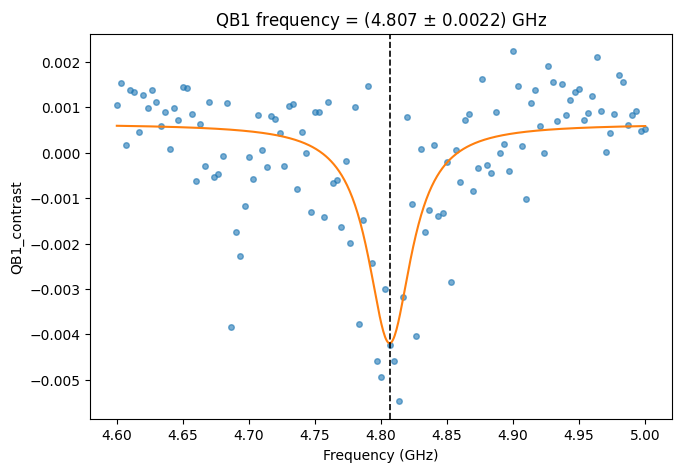

In [7]:
# Cell A2 — qubit spectroscopy: find the qubit through its readout-contrast dip
dimensions = {0: 3}                  # the transmon keeps 3 levels in the model
NN1 = a_dag * a_dag * a * a          # N(N-1), the anharmonic-ladder term

collapse_3lvl = [np.sqrt(1.0 / T1) * a, np.sqrt(2.0 * gamma_phi) * N]

ground = cudaq.State.from_data(np.array([1.0, 0.0, 0.0], dtype=np.complex128))

pulse_ns = 250.0
spec_schedule = Schedule(np.linspace(0.0, pulse_ns, 26), ["t"])
integrator = RungeKuttaIntegrator(order=4, max_step_size=0.2)

def spectroscopy_hamiltonian(f_drive, omega_drive):
    """Rotating-frame transmon Hamiltonian for one probe frequency/amplitude."""
    detuning = f01_true - f_drive
    return 2.0 * np.pi * (detuning * N + (alpha / 2.0) * NN1
                          + (omega_drive / 2.0) * (a + a_dag))

def sweep_excited_population(freq_list, omega):
    """One batched evolve — the GPU integrates every sweep point at once.

    Returns P(excited) = 1 - P(|0>) after the pulse; on a 3-level system
    <N> = P1 + 2*P2 and <N(N-1)> = 2*P2, so P(excited) = <N> - <N(N-1)>/2.
    """
    hams = [spectroscopy_hamiltonian(f, omega) for f in freq_list]
    results = cudaq.evolve(hams, dimensions, spec_schedule, ground,
                           collapse_operators=[collapse_3lvl] * len(hams),
                           observables=[N, NN1],
                           store_intermediate_results=cudaq.IntermediateResultSave.NONE,
                           integrator=integrator)
    populations = []
    for res in results:
        final = res.expectation_values()[-1]
        populations.append(final[0].expectation() - 0.5 * final[1].expectation())
    return np.array(populations)

freqs = f01_true + np.linspace(-0.20, 0.20, 121)   # GHz probe window: f01 +/- 200 MHz
omega_probe = 0.050                      # GHz  (strong probe -> power-broadened line)

t0 = time.perf_counter()
p_exc = sweep_excited_population(freqs, omega_probe)
print(f"{len(freqs)} simulations in one batched evolve call: "
      f"{time.perf_counter() - t0:.0f} s")

# What a real lab plot shows is not population but READOUT CONTRAST — the raw
# dispersive-readout signal (arbitrary units). Exciting the qubit pulls the
# contrast DOWN, so the qubit appears as a dip.
contrast_ground = 0.0012                 # readout signal with the qubit in |0>
contrast_excited = -0.0052               # readout signal with the qubit excited
contrast = contrast_ground + (contrast_excited - contrast_ground) * p_exc
contrast_meas = contrast + rng.normal(0.0, 0.0005, size=contrast.shape)

guess = [contrast_ground, 0.006, freqs[np.argmin(contrast_meas)], 0.05]
spec_popt, spec_pcov = fit_dip(freqs, contrast_meas, p0=guess)
assert spec_popt is not None, "no dip found — restore f01_true (A1) / freqs (A2) first"
f01_fit = spec_popt[2]
f01_err = np.sqrt(np.diag(spec_pcov))[2]
print(f"fitted f01 = ({f01_fit:.3f} +/- {f01_err:.4f}) GHz   (truth {f01_true:.4f} GHz)")

f_fine = np.linspace(freqs[0], freqs[-1], 600)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(freqs, contrast_meas, s=16, alpha=0.6)
ax.plot(f_fine, lorentzian_dip(f_fine, *spec_popt), color="tab:orange")
ax.axvline(f01_fit, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("QB1_contrast")
ax.set_title(f"QB1 frequency = ({f01_fit:.3f} $\\pm$ {f01_err:.4f}) GHz")
fig.savefig(f"{plot_dir}/qubit_spectroscopy.png", dpi=150, bbox_inches="tight")
plt.show()

### A.3 · Rabi oscillation — calibrate the $\pi$ pulse

Park the drive exactly on resonance ($f_d = f_{01}$): the detuning term vanishes and the
population flops sinusoidally at the drive amplitude $\Omega$,
$P_1(t) \approx \tfrac12\left(1 - \cos(2\pi\Omega t)\right)$. The first maximum is the
**$\pi$-pulse duration** $t_\pi = 1/(2\Omega)$ — the single most-used number in the control
stack. The anharmonicity term is doing quiet work: it keeps the drive from climbing past
$\lvert 1\rangle$ into $\lvert 2\rangle$ (the printed *leakage* checks this). We fit a
decaying cosine; the decay constant is barely constrained over 400 ns, so it is bounded
loosely and not reported. This plot is a good one for a **Q4 fit-reliability** question.

max leakage into |2>: 0.0011
fitted f_rabi = 9.987 MHz   (truth 10.000 MHz)
fitted t_pi   = 50.07 ns    (truth 50.00 ns)


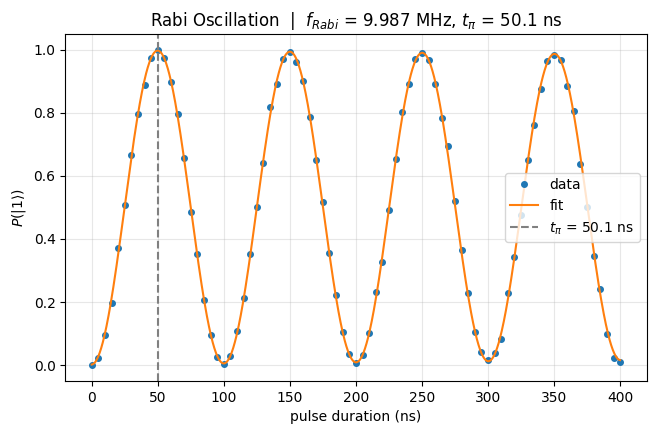

In [8]:
# Cell A3 — Rabi oscillation: drive on resonance, calibrate the pi pulse
omega_rabi = 0.010        # GHz drive amplitude -> 10 MHz Rabi frequency

rabi_hamiltonian = 2.0 * np.pi * ((alpha / 2.0) * NN1
                                  + (omega_rabi / 2.0) * (a + a_dag))

def proj1_matrix(dimension: int, **kwargs):
    mat = np.zeros((dimension, dimension), dtype=np.complex128)
    mat[1, 1] = 1.0
    return mat

def proj2_matrix(dimension: int, **kwargs):
    mat = np.zeros((dimension, dimension), dtype=np.complex128)
    mat[2, 2] = 1.0
    return mat

operators.define("proj1", [0], proj1_matrix)
operators.define("proj2", [0], proj2_matrix)
proj1 = operators.instantiate("proj1", [0])
proj2 = operators.instantiate("proj2", [0])

rabi_times = np.linspace(0.0, 400.0, 801)
result = cudaq.evolve(rabi_hamiltonian, dimensions, Schedule(rabi_times, ["t"]),
                      InitialState.ZERO,
                      collapse_operators=collapse_3lvl,
                      observables=[proj1, proj2],
                      store_intermediate_results=cudaq.IntermediateResultSave.EXPECTATION_VALUE,
                      integrator=integrator)

exp_vals = result.expectation_values()          # indexed [time step][observable]
rabi_P1 = np.array([step[0].expectation() for step in exp_vals])
rabi_P2 = np.array([step[1].expectation() for step in exp_vals])
print(f"max leakage into |2>: {np.max(rabi_P2):.4f}")

pick = np.linspace(0, len(rabi_times) - 1, 81).astype(int)
rabi_t_meas = rabi_times[pick]
rabi_P1_meas = measure(rabi_P1[pick])

def rabi_model(t, offset, amplitude, f_rabi, phi, tau):
    return offset + amplitude * np.cos(2.0 * np.pi * f_rabi * t + phi) * np.exp(-t / tau)

# tau is barely constrained over 400 ns (T1 and T2* are 25-60x longer), so it
# is bounded loosely and not reported as a calibrated value.
rabi_popt, _ = curve_fit(rabi_model, rabi_t_meas, rabi_P1_meas,
                         p0=[0.5, -0.5, 0.010, 0.0, 20000.0],
                         bounds=([0.0, -1.0, 0.001, -np.pi, 1000.0],
                                 [1.0, 1.0, 0.100, np.pi, 1e6]))
f_rabi_fit = rabi_popt[2]
t_pi = 1.0 / (2.0 * f_rabi_fit)
print(f"fitted f_rabi = {f_rabi_fit * 1e3:.3f} MHz   (truth {omega_rabi * 1e3:.3f} MHz)")
print(f"fitted t_pi   = {t_pi:.2f} ns    (truth {1.0 / (2.0 * omega_rabi):.2f} ns)")

t_fine = np.linspace(0.0, 400.0, 1001)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(rabi_t_meas, rabi_P1_meas, "o", markersize=4, label="data")
ax.plot(t_fine, rabi_model(t_fine, *rabi_popt), "-", label="fit")
ax.axvline(t_pi, linestyle="--", color="gray", label=f"$t_\\pi$ = {t_pi:.1f} ns")
ax.set_xlabel("pulse duration (ns)")
ax.set_ylabel(r"$P(|1\rangle)$")
ax.set_title(f"Rabi Oscillation  |  $f_{{Rabi}}$ = {f_rabi_fit * 1e3:.3f} MHz, "
             f"$t_\\pi$ = {t_pi:.1f} ns")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(f"{plot_dir}/rabi_oscillation.png", dpi=150, bbox_inches="tight")
plt.show()

### A.4 · $T_1$ relaxation — how long does $\lvert 1\rangle$ live?

Flip the qubit to $\lvert 1\rangle$ (on hardware: one calibrated $\pi$ pulse), wait a variable
delay, measure. Energy leaks to the environment and $P_1(t) = e^{-t/T_1}$. In the master
equation the *collapse operator is the experiment*: $\sqrt{1/T_1}\,\hat a$, with a zero
Hamiltonian in the rotating frame — nothing coherent happens, the qubit just sits and decays.
Two levels suffice (no drive, so $\lvert 2\rangle$ is never reached). On real hardware $T_1$
drifts by the hour — the reason calibration is a loop, not a one-time setup. For the
**dying-qubit** scenario, set `T1 = 3000` *and* `T2_star = 4000` in Cell A1 and re-run
(keep $T_2^* \le 2T_1$, or the pure-dephasing rate turns negative).

fitted T1 = 24.96 us   (truth 25.00 us)


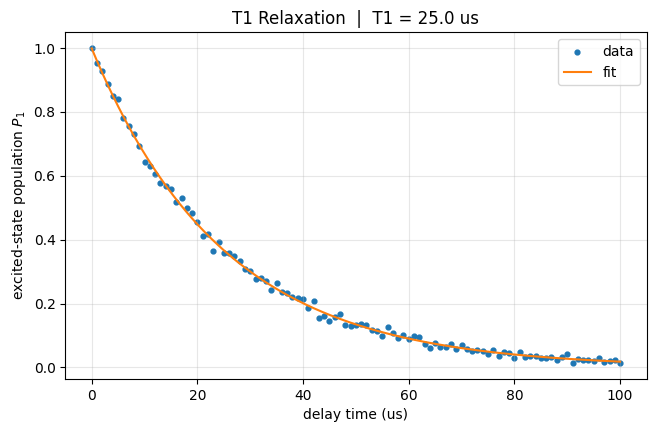

In [9]:
# Cell A4 — T1 relaxation: prepare |1>, wait, watch the energy leak away
dims_qubit = {0: 2}       # no drive -> nothing reaches |2>, two levels suffice

t1_hamiltonian = 2.0 * np.pi * 0.0 * operators.number(0)
t1_collapse = [np.sqrt(1.0 / T1) * operators.annihilate(0)]
excited = cudaq.State.from_data(np.array([0.0, 1.0], dtype=np.complex128))

t1_times = np.linspace(0.0, 100000.0, 101)       # delays from 0 to 100 us
result = cudaq.evolve(t1_hamiltonian, dims_qubit, Schedule(t1_times, ["t"]),
                      excited,
                      collapse_operators=t1_collapse,
                      observables=[operators.number(0)],     # <N> = P1 on a qubit
                      store_intermediate_results=cudaq.IntermediateResultSave.EXPECTATION_VALUE,
                      integrator=RungeKuttaIntegrator(order=4, max_step_size=100.0))

t1_P1 = np.array([step[0].expectation() for step in result.expectation_values()])
t1_P1_meas = measure(t1_P1)

def decay_model(t, amplitude, t1, offset):
    return amplitude * np.exp(-t / t1) + offset

t1_popt, _ = curve_fit(decay_model, t1_times, t1_P1_meas, p0=[1.0, 20000.0, 0.0])
T1_fit = t1_popt[1]
print(f"fitted T1 = {T1_fit / 1e3:.2f} us   (truth {T1 / 1e3:.2f} us)")

t_fine = np.linspace(0.0, 100000.0, 500)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(t1_times / 1e3, t1_P1_meas, s=12, label="data")
ax.plot(t_fine / 1e3, decay_model(t_fine, *t1_popt), "-", color="C1", label="fit")
ax.set_xlabel("delay time (us)")
ax.set_ylabel("excited-state population $P_1$")
ax.set_title(f"T1 Relaxation  |  T1 = {T1_fit / 1e3:.1f} us")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(f"{plot_dir}/t1_relaxation.png", dpi=150, bbox_inches="tight")
plt.show()

### A.5 · Ramsey fringes — frequency error and $T_2^*$

The precision tool: two $\pi/2$ pulses separated by a variable delay. We deliberately detune
the drive from the qubit by $\Delta f = 0.4$ MHz, so the qubit accumulates phase
$2\pi\,\Delta f\,t$ during the free evolution and the population fringes at *exactly the
detuning*, with the envelope decaying as $T_2^*$:

$$P_1(t) = \tfrac12\left(1 + \cos(2\pi\,\Delta f\,t)\,e^{-t/T_2^*}\right).$$

Simulation shortcut (honestly disclosed): the $\pi/2$ pulses are ideal — the free evolution
starts in $\lvert + \rangle = (\lvert 0\rangle + \lvert 1\rangle)/\sqrt2$, and the second
$\pi/2$ is the mapping $P_1 = (1 + \langle\sigma_x\rangle)/2$. Two calibration numbers in one
plot: the fringe frequency is the frequency error (how you fine-tune $f_{01}$ far beyond the
spectroscopy linewidth), and the envelope is $T_2^*$ — phase coherence, the resource
entanglement actually consumes ($T_2^* \le 2T_1$).

fitted detuning = 0.4005 MHz   (truth 0.4000 MHz)
fitted T2*      = 9.86 us       (truth 10.00 us)


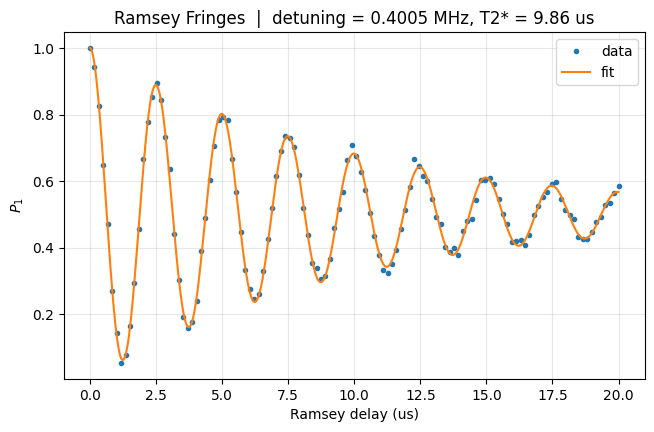

In [10]:
# Cell A5 — Ramsey fringes: detune on purpose, read the frequency error back
delta_ramsey = 0.0004     # GHz — the drive is deliberately 0.4 MHz off the qubit

ramsey_hamiltonian = 2.0 * np.pi * delta_ramsey * operators.number(0)
ramsey_collapse = [np.sqrt(1.0 / T1) * operators.annihilate(0),
                   np.sqrt(2.0 * gamma_phi) * operators.number(0)]
plus = cudaq.State.from_data(np.array([1.0, 1.0], dtype=np.complex128) / np.sqrt(2.0))

ramsey_times = np.linspace(0.0, 20000.0, 2001)   # delays from 0 to 20 us
result = cudaq.evolve(ramsey_hamiltonian, dims_qubit, Schedule(ramsey_times, ["t"]),
                      plus,
                      collapse_operators=ramsey_collapse,
                      observables=[spin.x(0)],
                      store_intermediate_results=cudaq.IntermediateResultSave.EXPECTATION_VALUE)

# the second pi/2 pulse maps the coherence onto population: P1 = (1 + <x>)/2
exp_x = np.array([step[0].expectation() for step in result.expectation_values()])
ramsey_P1 = (1.0 + exp_x) / 2.0

pick = np.linspace(0, len(ramsey_times) - 1, 120).astype(int)
ramsey_t_meas = ramsey_times[pick]
ramsey_P1_meas = measure(ramsey_P1[pick])

def ramsey_model(t, offset, amplitude, freq, phase, T2):
    return offset + amplitude * np.cos(2.0 * np.pi * freq * t + phase) * np.exp(-t / T2)

ramsey_popt, _ = curve_fit(ramsey_model, ramsey_t_meas, ramsey_P1_meas,
                           p0=[0.5, 0.5, 0.0004, 0.0, 10000.0])
detuning_fit = ramsey_popt[2]
T2_fit = ramsey_popt[4]
print(f"fitted detuning = {detuning_fit * 1e3:.4f} MHz   (truth {delta_ramsey * 1e3:.4f} MHz)")
print(f"fitted T2*      = {T2_fit / 1e3:.2f} us       (truth {T2_star / 1e3:.2f} us)")

t_fine = np.linspace(0.0, 20000.0, 1000)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(ramsey_t_meas / 1e3, ramsey_P1_meas, "o", markersize=3, label="data")
ax.plot(t_fine / 1e3, ramsey_model(t_fine, *ramsey_popt), "-", label="fit")
ax.set_xlabel("Ramsey delay (us)")
ax.set_ylabel("$P_1$")
ax.set_title(f"Ramsey Fringes  |  detuning = {detuning_fit * 1e3:.4f} MHz, "
             f"T2* = {T2_fit / 1e3:.2f} us")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(f"{plot_dir}/ramsey_fringes.png", dpi=150, bbox_inches="tight")
plt.show()

### A.6 · Case study — a drifting resonator (can the agent catch it?)

So far the agent has only seen *healthy* measurements. Real resonators do not sit still:
the fridge stage warms by a millikelvin, two-level-system defects switch, and $f_r$ wanders —
a calibration that was perfect an hour ago silently goes stale. That is why calibration is a
loop, not a one-time setup, and exactly the failure mode agents like Ising Calibration 1 are
meant to catch. The standard detection is simple: **repeat the scan and compare**.

The protocol is exactly Cell 3's — one frozen Hamiltonian per sweep point — except $f_r$
now depends on *when* point $k$ is measured ($x_k = k/100$, the progress through a scan):

$$H_k/\hbar = 2\pi\,\big(f_r(x_k) - f_{p,k}\big)\,\hat N \;+\; 2\pi\,\frac{\varepsilon}{2}\,(\hat a + \hat a^\dagger),
\qquad f_r(x_k) = f_r + \delta_1 x_k \;\;(+\;\delta_2\ \text{for scan 2}),$$

with $\delta_1 = 2$ MHz within each scan, $\delta_2 = 4$ MHz between scans; drive and photon
loss untouched. (Freezing $f_r$ per point is exact here — drift is minutes-slow against the
$\sim 2\ \mu s$ ring-up, nowhere near the rapid-scan regime $\dot f_p \sim \kappa^2$.) One
batched `evolve` integrates all 202 points — two scans concatenated.

Below, the dip lands about 4 MHz — roughly three linewidths — higher in the repeated scan.
We hand the two-dip plot to the agent with an open question, no status list and no hints: is
this device stable, what could cause it, and how should a system with this kind of error be
calibrated?

202 simulations in one batched evolve call: 5 s
scan 1 fitted f_r = 7.25112 GHz
scan 2 fitted f_r = 7.25557 GHz
apparent drift    = 4.45 MHz between scans


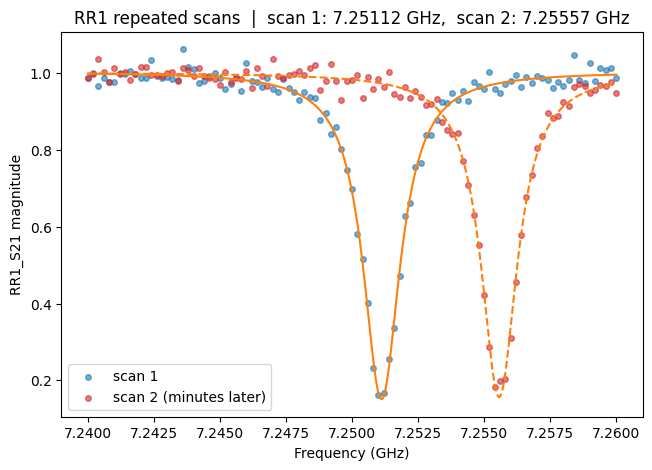

In [11]:
# Cell A6 — the drift case: two scans of a resonator that will not sit still
# The resonator warms and drifts upward DURING the session: it slides ~2 MHz
# across each scan, and sits ~4 MHz higher when the scan is repeated. One
# batched evolve simulates both scans — one Hamiltonian per (scan, probe) point.
progress = np.linspace(0.0, 1.0, len(res_freqs))         # 0 -> 1 across one scan
f_r_scan1 = f_r_true + 0.002 * progress                  # GHz, drifting during scan 1
f_r_scan2 = f_r_true + 0.004 + 0.002 * progress          # GHz, a few minutes later

drift_hams = [2.0 * np.pi * ((fr - fp) * N + (epsilon / 2.0) * (a + a_dag))
              for f_r_scan in (f_r_scan1, f_r_scan2)
              for fr, fp in zip(f_r_scan, res_freqs)]

t0 = time.perf_counter()
drift_results = cudaq.evolve(drift_hams, dims_res,
                             Schedule(ring_up_ts, ["t"]),
                             res_vacuum,
                             collapse_operators=[res_collapse] * len(drift_hams),
                             observables=[N],
                             store_intermediate_results=cudaq.IntermediateResultSave.NONE,
                             integrator=RungeKuttaIntegrator(order=4, max_step_size=1.0))
n_drift = steady_n(drift_results)
print(f"{len(drift_hams)} simulations in one batched evolve call: "
      f"{time.perf_counter() - t0:.0f} s")

n_scan1, n_scan2 = np.split(n_drift, 2)
s21_scan1 = to_s21(n_scan1)
s21_scan2 = to_s21(n_scan2)

popt1, _ = fit_dip(res_freqs, s21_scan1)
popt2, _ = fit_dip(res_freqs, s21_scan2)
assert popt1 is not None and popt2 is not None, \
    "no dip found — restore f_r_true / res_freqs (Cells 2-3) before this cell"
print(f"scan 1 fitted f_r = {popt1[2]:.5f} GHz")
print(f"scan 2 fitted f_r = {popt2[2]:.5f} GHz")
print(f"apparent drift    = {(popt2[2] - popt1[2]) * 1e3:.2f} MHz between scans")

drift_path = f"{plot_dir}/resonator_drift.png"
rf_fine = np.linspace(res_freqs[0], res_freqs[-1], 800)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(res_freqs, s21_scan1, s=16, alpha=0.6, label="scan 1")
ax.scatter(res_freqs, s21_scan2, s=16, alpha=0.6, color="tab:red",
           label="scan 2 (minutes later)")
ax.plot(rf_fine, lorentzian_dip(rf_fine, *popt1), color="tab:orange")
ax.plot(rf_fine, lorentzian_dip(rf_fine, *popt2), color="tab:orange", linestyle="--")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("RR1_S21 magnitude")
ax.set_title(f"RR1 repeated scans  |  scan 1: {popt1[2]:.5f} GHz,  "
             f"scan 2: {popt2[2]:.5f} GHz")
ax.legend()
fig.savefig(drift_path, dpi=150, bbox_inches="tight")
plt.show()

### A.7 · Dispersive readout — the resonator sees the qubit

The finale is *why* resonator spectroscopy comes first: the resonator is the qubit's
readout. Couple the transmon to the cavity with strength $g$, detuned by
$\Delta = f_{01} - f_r$ with $|\Delta| \gg g$, and to second order the Jaynes–Cummings
interaction reduces to the **dispersive Hamiltonian** of circuit QED
([Blais *et al.*, PRA **69**, 062320 (2004)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.69.062320), Eq. (12)):

$$H/\hbar = 2\pi\,\big(f_r - f_p + \chi\,\sigma_z\big)\,\hat N
\;+\; 2\pi\,\frac{\varepsilon}{2}\,(\hat a + \hat a^\dagger).$$

No energy is exchanged — the qubit simply **pulls the resonator by $\pm\chi$** depending on
its state.

The transmon here is the same three-level ladder as in A.2–A.3, so *both* of its transitions
couple to the cavity: $\lvert 0\rangle\!\to\!\lvert 1\rangle$ with strength $g$ at
detuning $\Delta$, and $\lvert 1\rangle\!\to\!\lvert 2\rangle$ with strength
$\sqrt2\,g$ at detuning $\Delta + \alpha$. The second pulls the cavity the opposite way, and
the state-dependent shift is what survives of the two
([Krantz *et al.*, arXiv:1904.06560](https://arxiv.org/abs/1904.06560), Eq. (146)):

$$\chi = \chi_{01} - \frac{\chi_{12}}{2}
= \frac{g^2}{\Delta} - \frac{g^2}{\Delta + \alpha}
= \frac{g^2\,\alpha}{\Delta\,(\Delta + \alpha)}.$$

Useful readout needs $2|\chi| \gtrsim \kappa$. With this device's $\Delta = -2.45$ GHz and
$\alpha = -220$ MHz, that calls for **strong coupling**: $g = 200$ MHz — still
$g/|\Delta| = 0.08 \ll 1$, safely dispersive — gives $\chi \approx -1.3$ MHz and puts the
two dips $2|\chi| \approx 2.7$ MHz, nearly two linewidths, apart.

Signs decide which dip is which. Here $\Delta < 0$, so $\chi < 0$; the dispersive
Hamiltonian is written with $\sigma_z = -1$ in the *ground* state, which pushes the
$\lvert 0\rangle$ resonance **up** and $\lvert 1\rangle$ **down** — the ordering plotted in
Fig. 19(b) of the same reference. (CUDA-Q's `spin.z` uses the opposite convention,
$\lvert 0\rangle \to +1$, so the cell negates it.)

The cell repeats Cell 3's sweep on the composite qubit ⊗ cavity system (the first true
two-body simulation in this notebook: `dimensions = {0: 6, 1: 2}`), once with the qubit in
$\lvert 0\rangle$ and once flipped to $\lvert 1\rangle$ by the $\pi$ pulse calibrated in
A.3. Telling those two dips apart in a single shot *is* qubit readout: every measurement in
this notebook was, on real hardware, taken through exactly this mechanism.

chi = -1.35 MHz  -> splitting 2.69 MHz vs kappa 1.50 MHz


202 simulations in one batched evolve call: 7 s
qubit |0>: fitted dip at 7.25133 GHz
qubit |1>: fitted dip at 7.24865 GHz
measured splitting = 2.68 MHz (truth 2|chi| = 2.69 MHz)


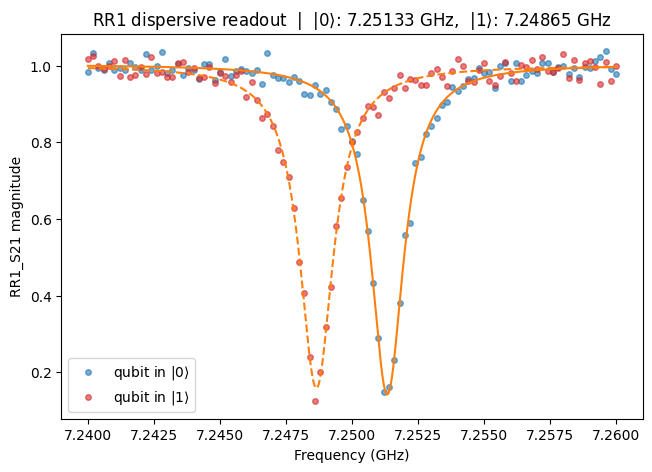

In [12]:
# Cell A7 — dispersive readout: the resonator dip moves with the qubit state
g_qr = 0.200                                   # GHz  coupling (strongly coupled device)
delta_qr = f01_true - f_r_true                 # GHz  detuning: qubit below resonator

# three-level transmon: the |1>-|2> transition pulls the cavity the other way,
# so the state-dependent shift is chi_01 - chi_12/2 (Krantz et al.,
# arXiv:1904.06560 Eq. 146 and Fig. 20). Delta < 0 here, so chi < 0.
chi = g_qr**2 * alpha / (delta_qr * (delta_qr + alpha))
print(f"chi = {chi * 1e3:+.2f} MHz  -> splitting {2 * abs(chi) * 1e3:.2f} MHz "
      f"vs kappa {kappa * 1e3:.2f} MHz")

dims_disp = {0: dims_res[0], 1: 2}   # the same cavity (degree 0) x qubit (degree 1)

# sigma_z in the dispersive-Hamiltonian convention is -1 in the GROUND state
# (Krantz Eq. 144), while CUDA-Q's spin.z gives |0> -> +1, so negate it. This
# is what puts the |0> dip ABOVE |1> for our Delta < 0 device (Krantz Fig. 19b).
sz = -spin.z(1)

disp_hams = [2.0 * np.pi * ((f_r_true - fp) * N + chi * sz * N
                            + (epsilon / 2.0) * (a + a_dag))
             for fp in res_freqs]

# initial states: cavity vacuum, qubit in |0> or flipped to |1> by the A.3 pi
# pulse — degree 1 is the slower index, so |cavity=0, qubit=1> sits at entry
# dims_disp[0]
dim_disp = dims_disp[0] * dims_disp[1]
psi_q0 = np.zeros(dim_disp, dtype=np.complex128)
psi_q0[0] = 1.0
psi_q1 = np.zeros(dim_disp, dtype=np.complex128)
psi_q1[dims_disp[0]] = 1.0

# both qubit states in ONE batched evolve: the same 101 Hamiltonians twice,
# zipped against a per-system list of initial states (A.6's concatenation idiom)
t0 = time.perf_counter()
disp_results = cudaq.evolve(disp_hams * 2, dims_disp,
                            Schedule(ring_up_ts, ["t"]),
                            [cudaq.State.from_data(psi_q0)] * len(res_freqs)
                            + [cudaq.State.from_data(psi_q1)] * len(res_freqs),
                            collapse_operators=[res_collapse] * (2 * len(res_freqs)),
                            observables=[N],
                            store_intermediate_results=cudaq.IntermediateResultSave.NONE,
                            integrator=RungeKuttaIntegrator(order=4, max_step_size=1.0))
n_disp = steady_n(disp_results)
print(f"{2 * len(res_freqs)} simulations in one batched evolve call: "
      f"{time.perf_counter() - t0:.0f} s")

n_q0, n_q1 = np.split(n_disp, 2)
s21_q0 = to_s21(n_q0)
s21_q1 = to_s21(n_q1)

popt_q0, _ = fit_dip(res_freqs, s21_q0)
popt_q1, _ = fit_dip(res_freqs, s21_q1)
assert popt_q0 is not None and popt_q1 is not None, \
    "no dip found — restore f_r_true / res_freqs (Cells 2-3) before the readout demo"
f_q0, f_q1 = popt_q0[2], popt_q1[2]
print(f"qubit |0>: fitted dip at {f_q0:.5f} GHz")
print(f"qubit |1>: fitted dip at {f_q1:.5f} GHz")
print(f"measured splitting = {abs(f_q0 - f_q1) * 1e3:.2f} MHz "
      f"(truth 2|chi| = {2 * abs(chi) * 1e3:.2f} MHz)")

rf_fine = np.linspace(res_freqs[0], res_freqs[-1], 800)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(res_freqs, s21_q0, s=16, alpha=0.6, label="qubit in $|0\\rangle$")
ax.scatter(res_freqs, s21_q1, s=16, alpha=0.6, color="tab:red",
           label="qubit in $|1\\rangle$")
ax.plot(rf_fine, lorentzian_dip(rf_fine, *popt_q0), color="tab:orange")
ax.plot(rf_fine, lorentzian_dip(rf_fine, *popt_q1), color="tab:orange",
        linestyle="--")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("RR1_S21 magnitude")
ax.set_title(f"RR1 dispersive readout  |  $|0\\rangle$: {f_q0:.5f} GHz,  "
             f"$|1\\rangle$: {f_q1:.5f} GHz")
ax.legend()
fig.savefig(f"{plot_dir}/dispersive_readout.png", dpi=150, bbox_inches="tight")
plt.show()

### A.8 · Exercise — your turn to query the agent

You now have seven plots from your own CUDA-Q simulations sitting in `calibration_plots/` —
the resonator scan (Cell 3) from the main flow, plus qubit spectroscopy, Rabi, $T_1$,
Ramsey, the drift doublet, and the dispersive-readout doublet from A.2–A.7. Pick one, write
your own QCalEval-style question (any of Q1–Q6 from Part I — the Rabi plot with a Q4 *fit
reliability* question is a nice one, or ask a Q3 about what the A.7 splitting means), and
send it with the `ask_agent(...)` helper from Cell 4. Then go further: change a parameter
in one of the cells (see the broken-experiment recipes in Part V), regenerate the plot, and
check whether the agent catches what you broke.

In [13]:
# Cell A8 — EXERCISE: pick a plot, write your own prompt, ask the agent

my_plot = "calibration_plots/..."       # TODO: pick a plot from calibration_plots/ (must include the ".png" extension)

my_question = (
    "..."                               # TODO: write your QCalEval-style question (Q1-Q6)
)

# TODO: uncomment once my_plot and my_question are filled in
# print(ask_agent(my_plot, my_question))